<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB_%EC%84%B8%EC%85%98(%EA%B8%88)/09_26_%EC%84%B8%EC%85%98_%EB%B9%84%EC%A7%80%EB%8F%84%ED%95%99%EC%8A%B5_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [1]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



1. 엘보우(Elbow) 기법

클러스터 개수가 늘어날수록 클러스터 내 거리 제곱합(WCSS, Within-Cluster Sum of Squares)이 감소합니다. 하지만 어느 지점부터는 감소 폭이 완만해집니다. 이 방법은 직관적이고 간단합니다.

2. 실루엣 기법
각 데이터가 자신의 클러스터 내에서 얼마나 잘 속하고, 다른 클러스터와 얼마나 잘 구분되는지를 측정합니다. 군집의 질을 수치적으로 평가 가능합니다.


### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


1. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘
- Mini-Batch K-means: 일반적인 K-means는 모든 데이터를 반복적으로 사용하기 때문에 대규모 데이터에서는 계산량이 큽니다.

2. 밀도가 높은 지역을 찾는 군집 알고리즘
- DBSCAN: 클러스터 수를 미리 지정하지 않아도 됩니다.

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


- 데이터가 여러 개의 가우시안(정규분포) 분포가 섞여서 생성되었다고 가정하는 모델입니다.

- 군집화, 밀도 추정, 분류, 이미지 처리/컴퓨터 비전

### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [4]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

X = olivetti.data
y = olivetti.target

####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# StratifiedShuffleSplit 초기화
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)

# 1차 분할: train / (valid+test)
for train_index, temp_index in sss.split(X, y):
    X_train, X_temp = X[train_index], X[temp_index]
    y_train, y_temp = y[train_index], y[temp_index]

# 2차 분할: (valid+test) → valid / test (0.5씩 나눠서 전체의 20%씩)
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for valid_index, test_index in sss_val.split(X_temp, y_temp):
    X_valid, X_test = X_temp[valid_index], X_temp[test_index]
    y_valid, y_test = y_temp[valid_index], y_temp[test_index]

####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [6]:
from sklearn.decomposition import PCA

# PCA 학습 (훈련 데이터에 맞춤)
pca = PCA(n_components=0.99, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# 검증, 테스트 데이터는 학습된 PCA로 변환
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 2~10개 클러스터에서 실루엣 점수 계산
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_pca)
    score = silhouette_score(X_train_pca, labels)
    silhouette_scores.append(score)

In [10]:
# 2. 최적 클러스터 개수 선택
best_k = K_range[np.argmax(silhouette_scores)]

In [11]:
# 3. 선택한 클러스터 수로 k-평균 모델 학습 및 라벨 할당
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_train_pca)

In [12]:
# 4. 결과(클러스터 개수, 라벨) 반환
best_k, cluster_labels

(2,
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       dtype=int32))

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [13]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

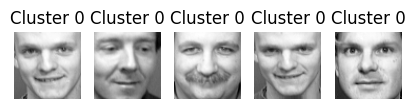

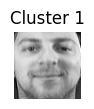

In [14]:
# 클러스터별로 얼굴 이미지 일부만 추출하여 시각화
for cluster in np.unique(cluster_labels):
    cluster_faces = X_train[cluster_labels == cluster]
    cluster_labels_for_plot = [f'Cluster {cluster}'] * min(5, len(cluster_faces))
    plot_faces(cluster_faces[:5], cluster_labels_for_plot)